In [15]:
pip install geopandas shapely pyproj adjustText matplotlib


Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install matplotlib-scalebar

Note: you may need to restart the kernel to use updated packages.


1. Trend of Wind_GWh Over Time (2010–2024)

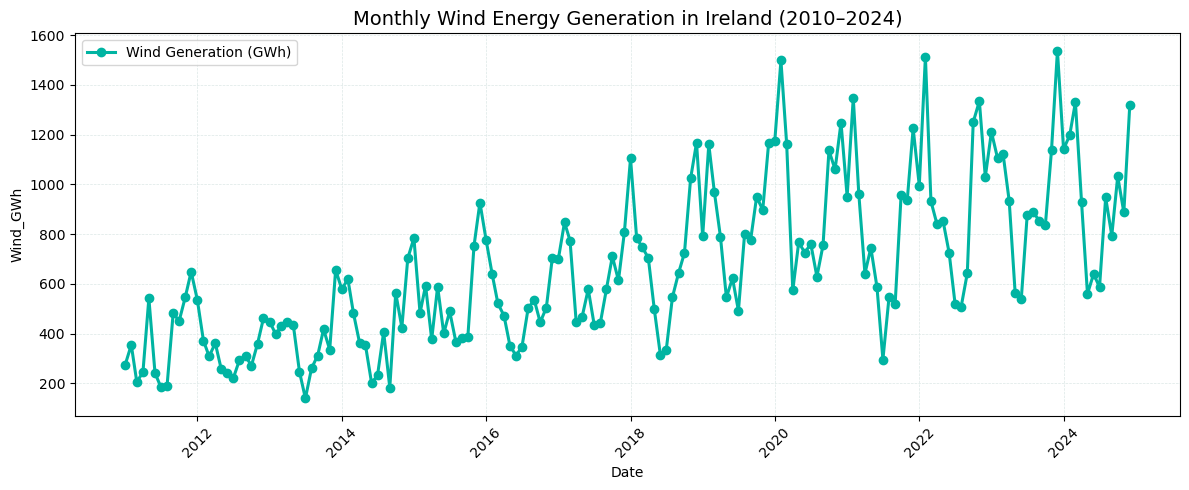

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

wind = pd.read_csv('../../data/processed/Final_Model_Wind.csv')

# Ensure datetime format
wind['Date'] = pd.to_datetime(wind['Date'])

seai_wind_color = "#00b4a2"

# Sortin date 
wind_sorted = wind.sort_values('Date')

# Creating figure and plot
plt.figure(figsize=(12, 5))
plt.plot(wind_sorted['Date'], wind_sorted['Wind_GWh'],
         marker='o', linewidth=2.2, color=seai_wind_color, label='Wind Generation (GWh)')

plt.title('Monthly Wind Energy Generation in Ireland (2010–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wind_GWh')
plt.grid(True, linestyle='--', linewidth=0.5, color='#dce7e6')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()

# Save
save_path = "../../outputs/figures/EDA_Wind/Wind_GWh_Trend.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


2. Installed Wind Capacity Over Time

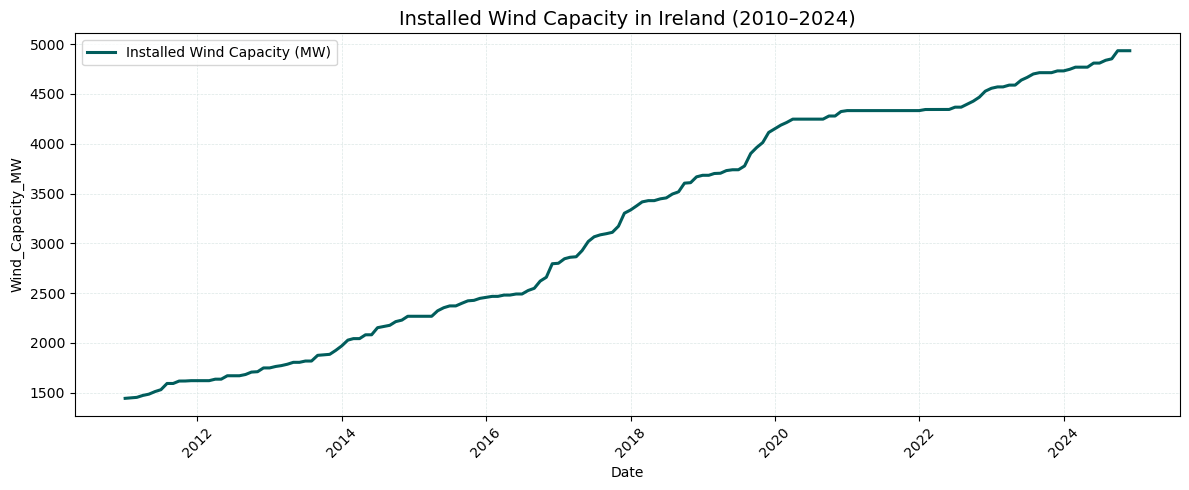

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

final_wind = pd.read_csv("../../data/processed/Final_Model_Wind.csv")
final_wind['Date'] = pd.to_datetime(final_wind['Date'])

seai_capacity_color = "#015d5c"
final_wind_sorted = final_wind.sort_values('Date')

plt.figure(figsize=(12, 5))
plt.plot(final_wind_sorted['Date'], final_wind_sorted['Wind_Capacity_MW'],
         color=seai_capacity_color, linewidth=2.2, label='Installed Wind Capacity (MW)')

plt.title('Installed Wind Capacity in Ireland (2010–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wind_Capacity_MW')
plt.grid(True, linestyle='--', linewidth=0.5, color='#dce7e6')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()

# Save
save_path = "../../outputs/figures/wind/Wind_Capacity_Trend.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


3. Correlation Matrix (Heatmap) to analyze relationships between Wind_GWh, weather features, and lagged predictors

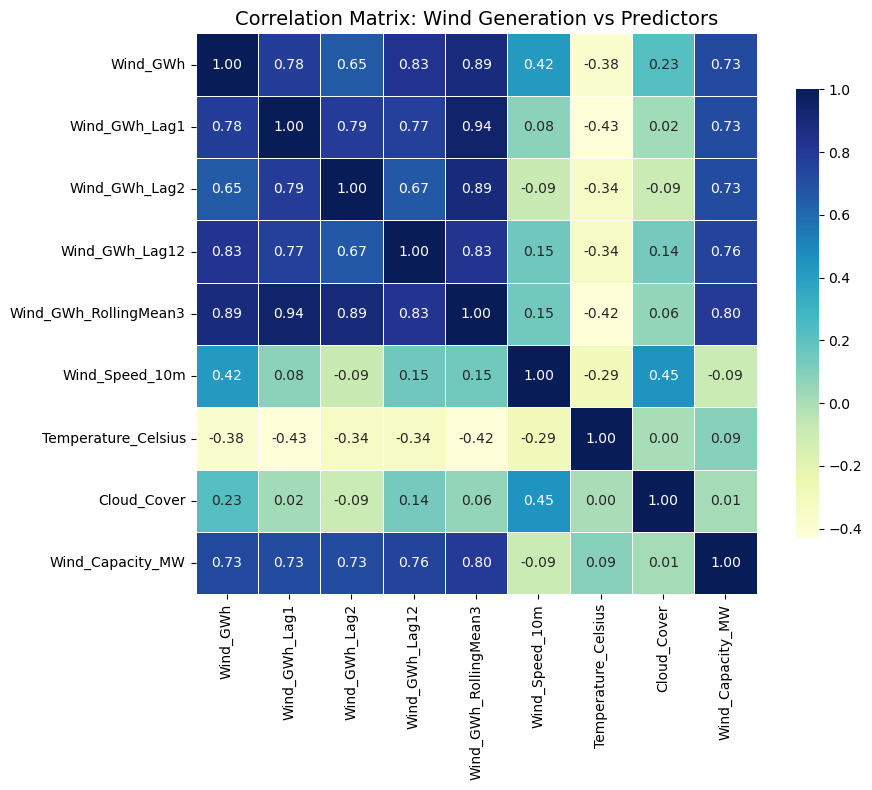

In [ ]:
import seaborn as sns
import numpy as np

# relevant columns for correlation matrix
cols_to_corr = [
    'Wind_GWh',
    'Wind_GWh_Lag1', 'Wind_GWh_Lag2', 'Wind_GWh_Lag12',
    'Wind_GWh_RollingMean3',
    'Wind_Speed_10m', 'Temperature_Celsius', 'Cloud_Cover',
    'Wind_Capacity_MW'
]

# Subset the dataframe
corr_data = final_wind[cols_to_corr]

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='YlGnBu', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Wind Generation vs Predictors", fontsize=14)
plt.tight_layout()

# Save 
save_path = "../../outputs/figures/wind/Wind_Correlation_Matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

4. Scatter Plot: Wind_GWh vs Wind_Speed_10m

In [ ]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_wind, x='Wind_Speed_10m', y='Wind_GWh', color="#1f77b4", edgecolor='black', alpha=0.7)
sns.regplot(data=final_wind, x='Wind_Speed_10m', y='Wind_GWh', scatter=False, color="#ff7f0e", line_kws={"linewidth": 2})

plt.title("Wind Generation vs Wind Speed (10m)", fontsize=14)
plt.xlabel("Wind Speed at 10m (m/s)")
plt.ylabel("Wind Generation (GWh)")
plt.grid(True, linestyle='--', linewidth=0.5, color='#dce7e6')
plt.tight_layout()

# Save
save_path = "../../outputs/figures/wind/EDA_wind/WindGWh_vs_WindSpeed.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


5. Boxplots of Wind_GWh by Month (to visualize seasonal variation in wind generation)

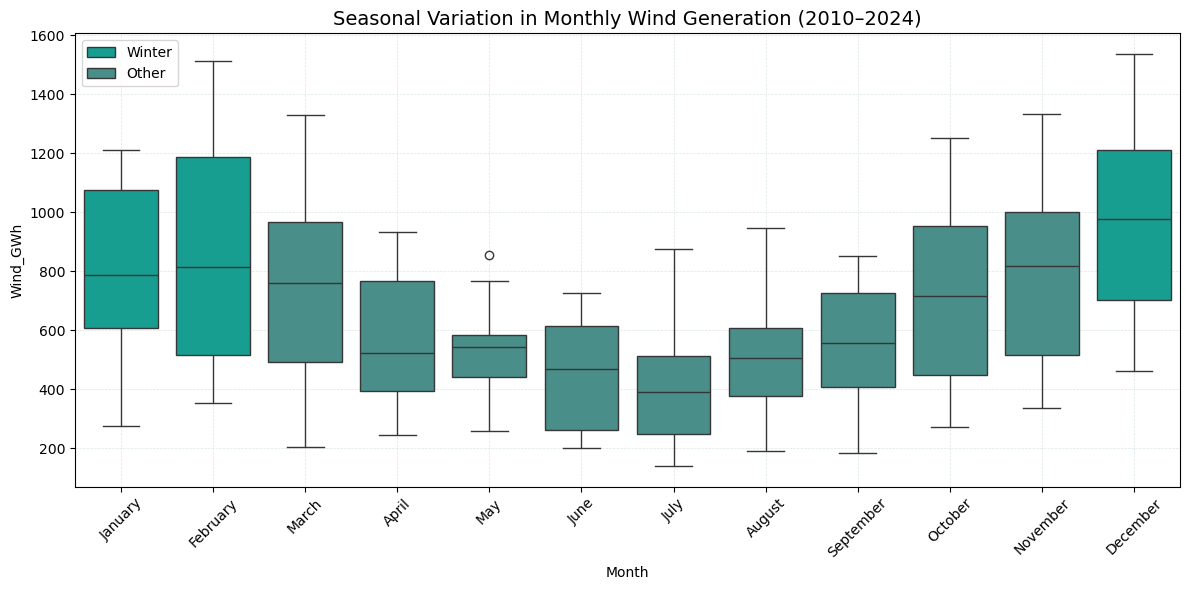

In [ ]:
# Adding a new column for seasonal hue grouping (Winter vs Non-Winter)
winter_months = ['December', 'January', 'February']
final_wind['Season'] = final_wind['Month'].apply(lambda m: 'Winter' if m in winter_months else 'Other')

# Boxplot, using `hue`
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=final_wind,
    x='Month',
    y='Wind_GWh',
    hue='Season',
    order=month_order,
    palette={'Winter': '#00b4a2', 'Other': '#3d9993'},
    dodge=False  # Ensuring only one box per month
)

plt.title('Seasonal Variation in Monthly Wind Generation (2010–2024)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Wind_GWh')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.5, color='#dce7e6')
plt.tight_layout()
plt.legend().set_title("") 

# Save 
plt.savefig("../../outputs/figures/wind/WindGWh_Seasonal_Boxplot.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


6. Lag Effects – Autocorrelation Plot

<Figure size 1000x500 with 0 Axes>

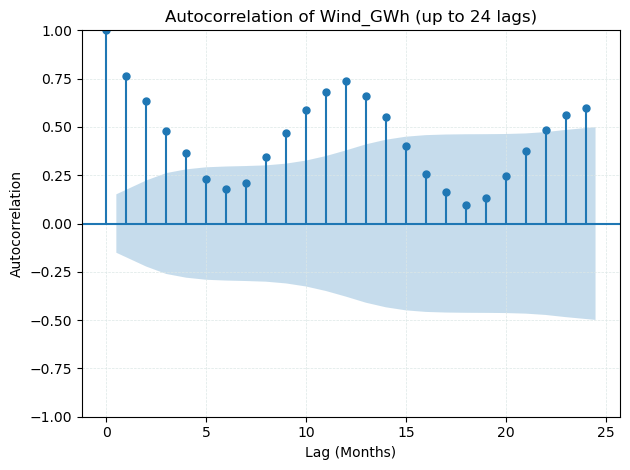

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot 7: Autocorrelation Function (ACF) for Wind_GWh
plt.figure(figsize=(10, 5))
plot_acf(final_wind['Wind_GWh'], lags=24, alpha=0.05, title="Autocorrelation of Wind_GWh (up to 24 lags)")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")
plt.grid(True, linestyle='--', linewidth=0.5, color='#dce7e6')
plt.tight_layout()

# Save
plt.savefig("../../outputs/figures/wind/WindGWh_ACF_Lags.png", dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


7. Pairplot of Selected Wind Features / Feature Relationships

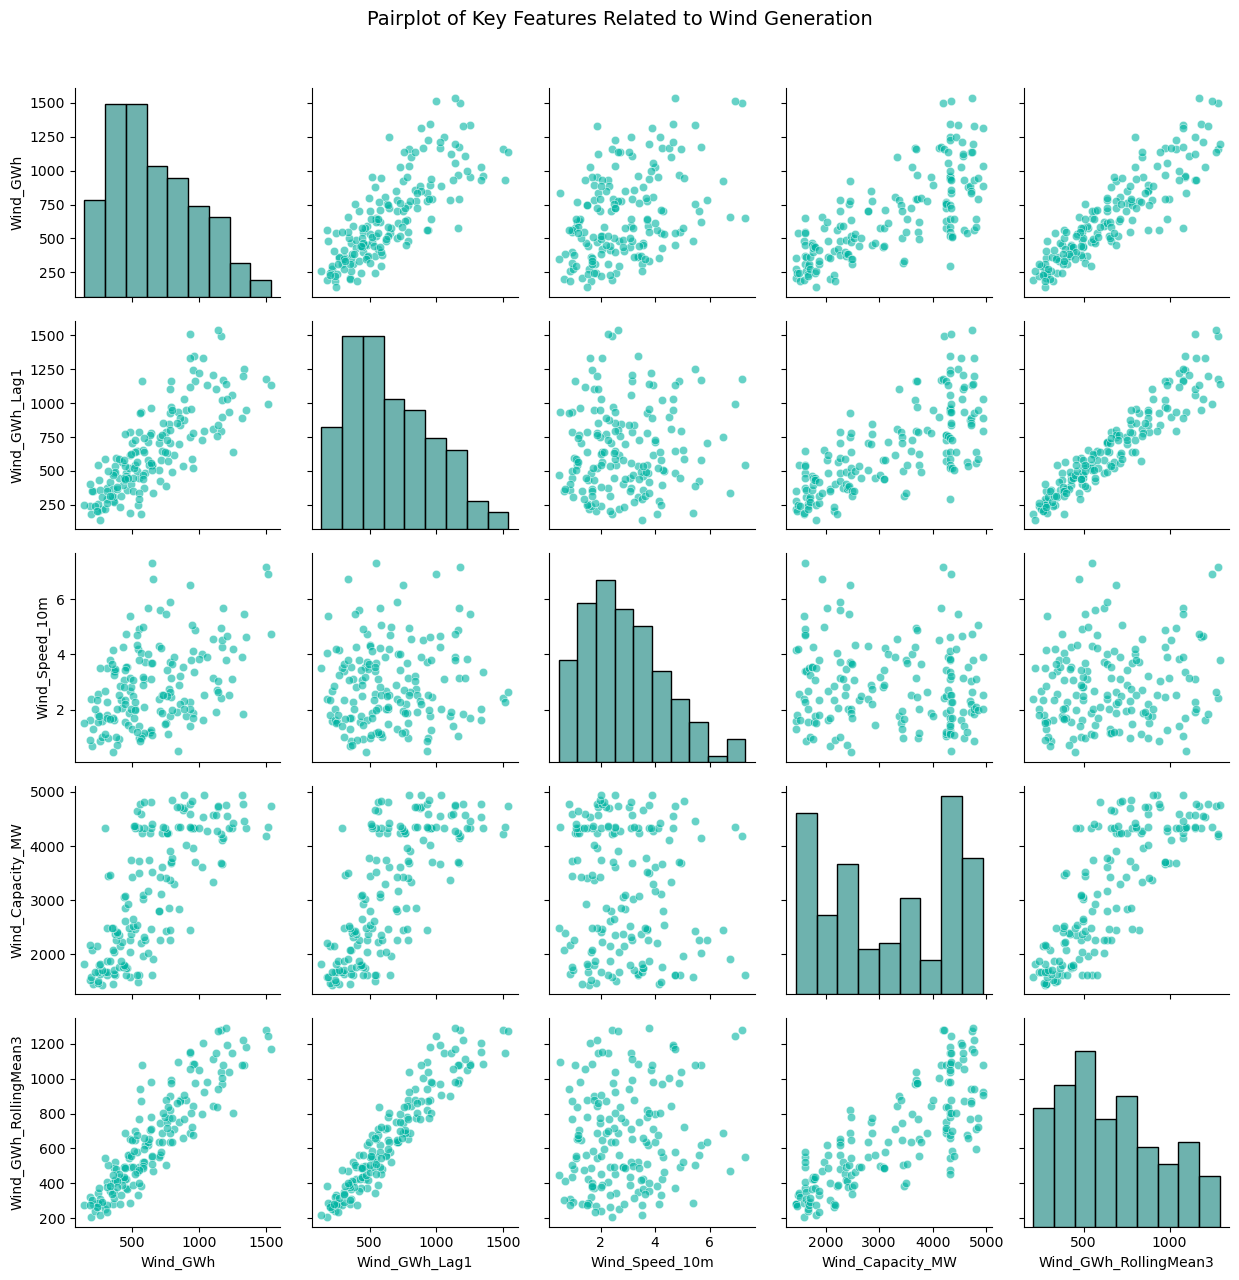

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Define the feature columns
pairplot_columns = [
    'Wind_GWh',
    'Wind_GWh_Lag1',
    'Wind_Speed_10m',
    'Wind_Capacity_MW',
    'Wind_GWh_RollingMean3'
]

# Prepared DataFrame
pairplot_df = final_wind[pairplot_columns].reset_index(drop=True).copy()
pairplot_df = pairplot_df.apply(pd.to_numeric, errors='coerce')
pairplot_df = pairplot_df.dropna()

# Create the pairplot
sns.pairplot(pairplot_df,
             diag_kind='hist',
             plot_kws={'alpha': 0.6, 'color': '#00b4a2'},
             diag_kws={'color': '#3d9993'})

# Title and layout
plt.suptitle("Pairplot of Key Features Related to Wind Generation", fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig("../../outputs/figures/wind/Wind_Feature_Pairplot.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


8. Wind_GWh vs Installed Capacity

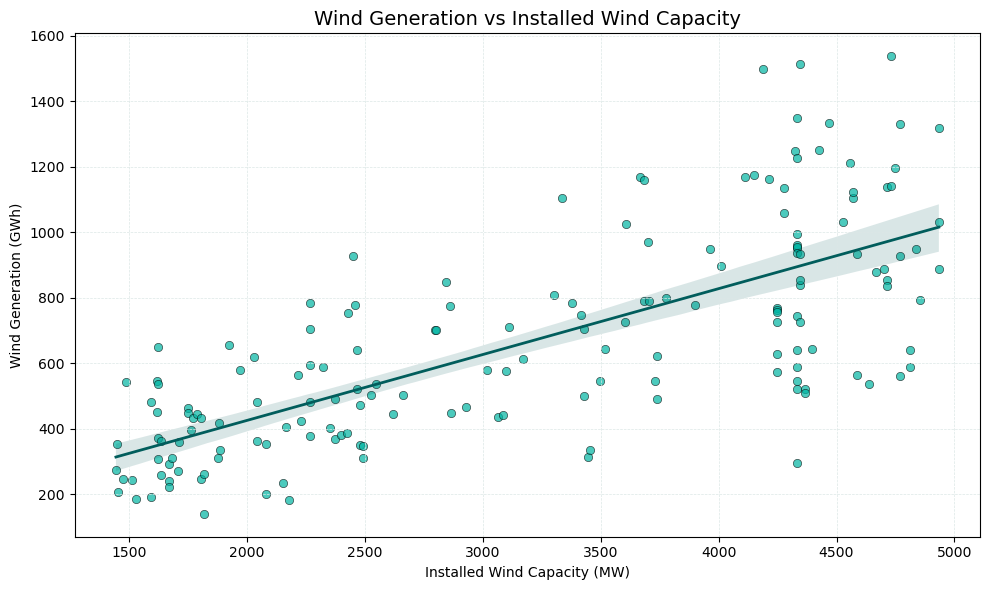

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_wind, x='Wind_Capacity_MW', y='Wind_GWh',
                color="#00b4a2", edgecolor='black', alpha=0.7)
sns.regplot(data=final_wind, x='Wind_Capacity_MW', y='Wind_GWh',
            scatter=False, color="#015d5c", line_kws={"linewidth": 2})

plt.title("Wind Generation vs Installed Wind Capacity", fontsize=14)
plt.xlabel("Installed Wind Capacity (MW)")
plt.ylabel("Wind Generation (GWh)")
plt.grid(True, linestyle='--', linewidth=0.5, color='#dce7e6')
plt.tight_layout()


plt.savefig("../../outputs/figures/wind/WindGWh_vs_Capacity.png", dpi=300, bbox_inches='tight', facecolor='white')

plt.show()


Map

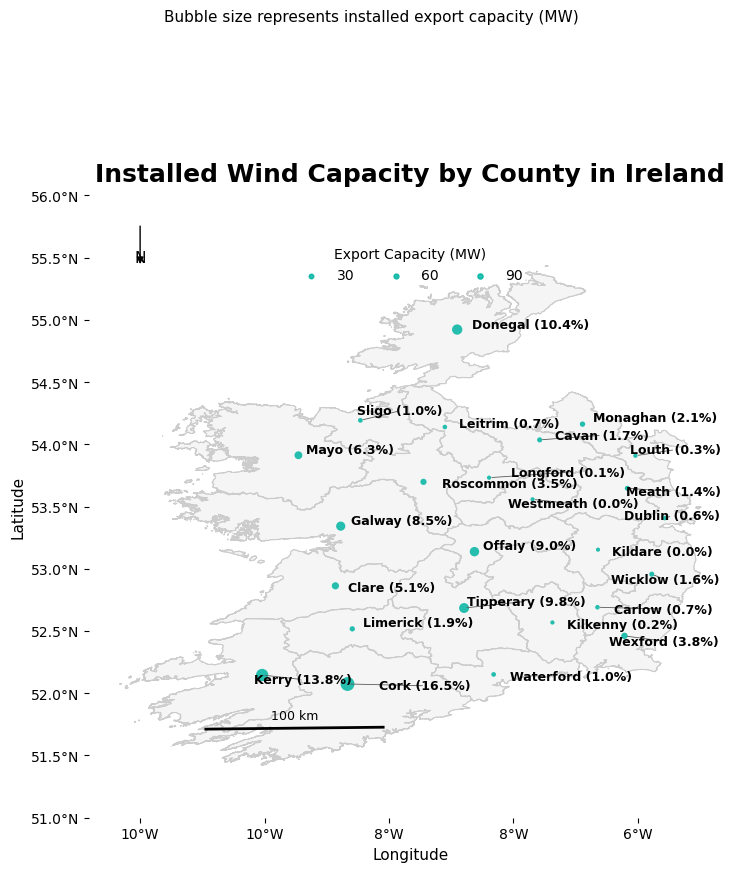

In [ ]:

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from adjustText import adjust_text
import pyproj
import os

SHP_DIR  = r"C:\Projects\GitHub\Ireland-energy-forecast\data\raw\gadm41_IRL_shp"
SHP_LYR  = "gadm41_IRL_1"  # county level
WIND_CSV = r"C:\Projects\GitHub\Ireland-energy-forecast\data\processed\Regional_capacity_wind\Aggregated_Wind_Capacity_By_County.csv"
OUT_PNG  = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\wind_capacity_map_final_clean.png"
os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)


def deg_lon_formatter(x, pos):  # -10 -> 10°W
    return f"{abs(x):.0f}°{'W' if x < 0 else 'E'}"

def deg_lat_formatter(y, pos):  # 53.5 -> 53.5°N
    return f"{abs(y):.1f}°{'N' if y >= 0 else 'S'}"

def draw_scalebar(ax, length_km=100, relx=0.18, rely=0.12,
                  crs_map=4326, crs_metric=2157, lw=2, txt_kw=None):
    """Accurate scalebar drawn via metric CRS (EPSG:2157)."""
    if txt_kw is None:
        txt_kw = dict(fontsize=9, ha="center", va="bottom")
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    ax_x = x0 + relx * (x1 - x0)
    ax_y = y0 + rely * (y1 - y0)

    to_m = pyproj.Transformer.from_crs(crs_map, crs_metric, always_xy=True)
    to_w = pyproj.Transformer.from_crs(crs_metric, crs_map, always_xy=True)

    xm, ym = to_m.transform(ax_x, ax_y)
    xm2 = xm + length_km * 1000.0
    xw1, yw1 = to_w.transform(xm,  ym)
    xw2, yw2 = to_w.transform(xm2, ym)

    ax.plot([xw1, xw2], [yw1, yw2], color="black", lw=lw, solid_capstyle="butt", zorder=5)
    ax.text((xw1 + xw2)/2, yw1 + 0.012*(y1 - y0), f"{length_km} km", **txt_kw)

# Load data
# GADM counties (WGS84)
try:
    ireland = gpd.read_file(SHP_DIR, layer=SHP_LYR)
except Exception:
    ireland = gpd.read_file(os.path.join(SHP_DIR, f"{SHP_LYR}.shp"))

s = ireland["NAME_1"]
s = s.where(~s.isna(), "cork")
ireland["NAME_1"] = (
    s.astype(str).str.strip().str.lower().replace({"na": "cork", "nan": "cork"})
)
ireland = ireland.to_crs(4326)

# Capacities
agg = pd.read_csv(WIND_CSV)
agg["County"] = agg["County"].astype(str).str.strip().str.lower()

# Join, keep rows with data
gdf = ireland.merge(agg, left_on="NAME_1", right_on="County", how="left")
gdf = gdf[~gdf["Installed_MW"].isna()].copy().drop(columns=["County"])

# Share labels
share = 100 * gdf["Installed_MW"] / gdf["Installed_MW"].sum()
gdf["Share_Label"] = gdf["NAME_1"].str.title() + " (" + share.round(1).astype(str) + "%)"

# Label/bubble coords via EPSG:2157 (stable interior points), back to WGS84
gdf_2157 = gdf.to_crs(2157)
pts_2157 = gdf_2157.representative_point()
pts_wgs  = pts_2157.to_crs(4326)
coords = np.vstack(pts_wgs.apply(lambda p: (p.x, p.y)).values)
gdf["X"], gdf["Y"] = coords[:, 0], coords[:, 1]

# Small nudge for Cork (to mirror your R layout)
mask_cork = gdf["NAME_1"].eq("cork")
gdf.loc[mask_cork, "X"] -= 0.25
gdf.loc[mask_cork, "Y"] += 0.15


fig, ax = plt.subplots(figsize=(8, 10))

# Remove all axes frames/borders
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)

# Base map
ireland.plot(ax=ax, color="#F5F5F5", edgecolor="#CCCCCC", linewidth=0.5, zorder=0)
ireland.boundary.plot(ax=ax, color="#CCCCCC", linewidth=0.8, zorder=1)

# Bubble sizes (map MW to radius; Matplotlib uses points^2)
mw = gdf["Installed_MW"].to_numpy()
r_min, r_max = 3, 10
r_pts = r_min + (mw - mw.min())/(mw.max() - mw.min() + 1e-12) * (r_max - r_min)
sizes = r_pts**2

ax.scatter(gdf["X"], gdf["Y"], s=sizes, marker="o",
           facecolor="#00B4A2", edgecolor="#00B4A2",
           alpha=0.85, linewidths=0, zorder=3)

# Labels with repel
texts = [
    ax.text(row.X, row.Y, row.Share_Label, fontsize=9, fontweight="bold",
            color="black", zorder=4)
    for row in gdf.itertuples()
]
adjust_text(
    texts, ax=ax,
    expand_text=(1.15, 1.25), expand_points=(1.2, 1.3),
    force_text=(0.05, 0.10), force_points=(0.15, 0.25),
    arrowprops=dict(arrowstyle="-", lw=0.6, color="0.35")
)

# Clamp labels inside map area prevents drifting outside
x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
pad_x = 0.06 * (x1 - x0)
pad_y = 0.04 * (y1 - y0)
for t in texts:
    x, y = t.get_position()
    x = max(x0 + pad_x, min(x1 - pad_x, x))
    y = max(y0 + pad_y, min(y1 - pad_y, y))
    t.set_position((x, y))

# Legend (30/60/90 MW) under subtitle
for ref in [30, 60, 90]:
    rp = r_min + (ref - mw.min())/(mw.max() - mw.min() + 1e-12) * (r_max - r_min)
    ax.scatter([], [], s=rp**2, color="#00B4A2", alpha=0.85, label=f"{ref}")
leg = ax.legend(title="Export Capacity (MW)",
                loc="upper center", bbox_to_anchor=(0.5, 0.93),
                ncol=4, frameon=False, borderaxespad=0.2)
plt.setp(leg.get_title(), fontsize=10)

# North arrow subtle, inset
ax.annotate("N", xy=(0.08, 0.90), xycoords="axes fraction",
            fontsize=11, ha="center", va="center")
ax.annotate("", xy=(0.08, 0.885), xytext=(0.08, 0.955), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=1.0, color="black"))

# Extent & aspect no stretching
minx, miny, maxx, maxy = ireland.total_bounds
ax.set_xlim(minx - 0.25, maxx + 0.25)
ax.set_ylim(miny - 0.25, maxy + 0.25)
ax.set_aspect("equal", adjustable="box")

# Accurate 100-km scalebar
draw_scalebar(ax, length_km=100, relx=0.18, rely=0.12)

# Title + subtitle (separate, clean stack)
ax.set_title("Installed Wind Capacity by County in Ireland",
             fontsize=18, fontweight="bold", pad=10)
fig.text(0.5, 0.965, "Bubble size represents installed export capacity (MW)",
         ha="center", va="center", fontsize=11)

# Axes labels + degree formatting
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.xaxis.set_major_formatter(FuncFormatter(deg_lon_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(deg_lat_formatter))
ax.set_xticks(np.arange(-10.5, -5.5, 1.0))
ax.set_yticks(np.arange(51.0, 56.1, 0.5))


plt.tight_layout(rect=[0.03, 0.05, 0.97, 0.90])
#plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight", pad_inches=0.1, facecolor="white", edgecolor="none")
plt.show()
#print(f" Saved: {OUT_PNG}")
